In [1]:
import os
import sys
import time
import copy
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# 路径设置（假设在 tagging/Baseline 目录下运行）
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import importlib
from model import ParticleTransformerKD  # noqa: E402
importlib.reload(tool)  # noqa: E402

# 可复现
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# 实验输出
RUN_NAME = 'hlt_effect_ablation'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 200000,
    'max_particles': 100,
    'hlt_effects': {
        # smear 参数（smear_enabled=True 时生效）
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,

        # 阈值（threshold_enabled=True 时生效）
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,

        # merge 参数（merge_enabled=True 时生效）
        'merge_enabled': True,
        'merge_radius': 0.01,

        # effloss（>0 时生效）
        'efficiency_loss': 0.03,

        # 消融开关：默认为保持原逻辑（threshold+smear 都开）
        'threshold_enabled': True,
        'smear_enabled': True,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'training': {
        'batch_size': 512,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 5,
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        # 如果设置为已有路径，会跳过训练并直接加载
        'load_offline': None,
        'load_threshold': None,
        'load_merge': None,
        'load_smear': None,
        'load_effloss': None,
    },
}

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])

# 扫描配置
SCAN = {
    # 重复次数（每个取值跑几次）
    'repeats': 3,
    # 每次重复的随机种子（同时影响：模型初始化/训练 shuffle；以及 smear/effloss 的随机实现）
    'run_seeds': [100, 101, 102],

    # 1) threshold 扫描：HLT threshold 从 0.5 提升到下列值
    # 'hlt_threshold_vals': [1.0, 1.5, 2.0],
    'hlt_threshold_vals': [1.5],

    # 2) resolution 扫描：相对缩放（50%/100%/150%）
    # 'resolution_scales': [0.5, 1.0, 1.5],
    'resolution_scales': [1.0],

    # 3) merge 扫描：merge_radius
    # 'merge_radii': [0.005, 0.01, 0.015],
    'merge_radii': [0.01],

    # 4) effloss 扫描
    # 'effloss_vals': [0.015, 0.03, 0.045],
    'effloss_vals': [0.03],

    # ROC 平均时使用的 FPR 网格（插值用）
    'fpr_grid_n': 201,
}


Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\Baseline\runs\hlt_effect_ablation


In [2]:
# 读取数据
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
masks_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))


Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164


In [3]:
# 基础：先做 OFFLINE pT 阈值（共同起点）
pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
masks_off = masks_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
constituents_off = constituents_raw.copy()
constituents_off[~masks_off] = 0

# split（所有实验共享同一套 index，保证可比）
idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed, stratify=labels[temp_idx])
print(f"Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")

# 预先计算 OFFLINE features（标准化统计也基于 OFFLINE TRAIN）
features_off = tool.compute_features(constituents_off, masks_off)
print('Offline features:', features_off.shape)

# 统一的 HLT 生成函数：以 baseline(hlt threshold=0.5，不开 smear/merge/effloss) 为参照

def make_hlt_variant(
    base_const,
    base_mask,
    *,
    # baseline：HLT threshold=0.5
    pt_thr_hlt: float = 0.5,
    threshold_enabled: bool = True,
    # smear
    smear_enabled: bool = False,
    res_scale: float = 1.0,
    # merge
    merge_enabled: bool = False,
    merge_radius: float = 0.01,
    # effloss
    efficiency_loss: float = 0.0,
    # seed
    run_seed: int = 42,
):
    cfg = copy.deepcopy(CONFIG)
    h = cfg['hlt_effects']

    # threshold
    h['threshold_enabled'] = bool(threshold_enabled)
    h['pt_threshold_hlt'] = float(pt_thr_hlt)

    # merge
    h['merge_enabled'] = bool(merge_enabled)
    h['merge_radius'] = float(merge_radius)

    # smear（resolution 用 scale 控制）
    h['smear_enabled'] = bool(smear_enabled)
    h['pt_resolution'] = float(CONFIG['hlt_effects']['pt_resolution']) * float(res_scale)
    h['eta_resolution'] = float(CONFIG['hlt_effects']['eta_resolution']) * float(res_scale)
    h['phi_resolution'] = float(CONFIG['hlt_effects']['phi_resolution']) * float(res_scale)

    # effloss
    h['efficiency_loss'] = float(efficiency_loss)

    return tool.apply_hlt_effects(base_const, base_mask, cfg, seed=int(run_seed))

# baseline HLT：offline/hlt threshold 都是 0.5，且其它 effect 全关
const_hlt_base, mask_hlt_base = make_hlt_variant(
    constituents_off,
    masks_off,
    pt_thr_hlt=float(CONFIG['hlt_effects']['pt_threshold_offline']),
    threshold_enabled=True,
    smear_enabled=False,
    merge_enabled=False,
    efficiency_loss=0.0,
    run_seed=seed,
)
features_hlt_base = tool.compute_features(const_hlt_base, mask_hlt_base)
print('HLT baseline features:', features_hlt_base.shape)


Split: train=140,000 val=30,000 test=30,000
Offline features: (200000, 100, 7)
HLT baseline features: (200000, 100, 7)


In [4]:
# 用 OFFLINE TRAIN 的统计量做标准化（保证可比）
feat_means_off, feat_stds_off = tool.get_stats(features_off, masks_off, train_idx)

features_off_std = tool.standardize(features_off, masks_off, feat_means_off, feat_stds_off, clip=10.0)
features_hlt_base_std = tool.standardize(features_hlt_base, mask_hlt_base, feat_means_off, feat_stds_off, clip=10.0)

print('Standardization done.')
print('Offline std:', features_off_std.shape)
print('HLT baseline std:', features_hlt_base_std.shape)

# 标准化工具函数（每次 scan 生成的 hlt features 用同一套离线统计量标准化）

def standardize_hlt(features_hlt: np.ndarray, mask_hlt: np.ndarray):
    return tool.standardize(features_hlt, mask_hlt, feat_means_off, feat_stds_off, clip=10.0)

Standardization done.
Offline std: (200000, 100, 7)
HLT baseline std: (200000, 100, 7)


In [5]:
# Scan utilities
from pathlib import Path

BS = int(CONFIG['training']['batch_size'])

epochs = int(CONFIG['training']['epochs'])
lr = float(CONFIG['training']['lr'])
wd = float(CONFIG['training']['weight_decay'])
warm = int(CONFIG['training']['warmup_epochs'])
pat = int(CONFIG['training']['patience'])

# 输出目录
RES_DIR = tool.ensure_dir(Path(OUT_DIR) / 'results')
CKPT_DIR = Path(CONFIG['io']['ckpt_dir'])


def _fmt_val(v: float) -> str:
    # 用于文件名（避免 '.'）
    s = f"{float(v):.6g}"
    return s.replace('.', 'p').replace('-', 'm')


def _set_seeds(s: int):
    # 训练可复现（不保证完全确定，但足够用于稳定性估计）
    torch.manual_seed(int(s))
    np.random.seed(int(s))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(s))


def _make_loaders(feat_hlt_std: np.ndarray, mask_hlt: np.ndarray, *, run_seed: int):
    # 让 shuffle 的顺序可复现
    g = torch.Generator()
    g.manual_seed(int(run_seed))

    train_ds = tool.JetDataset(
        features_off_std[train_idx],
        feat_hlt_std[train_idx],
        labels[train_idx],
        masks_off[train_idx],
        mask_hlt[train_idx],
        weights[train_idx],
    )
    val_ds = tool.JetDataset(
        features_off_std[val_idx],
        feat_hlt_std[val_idx],
        labels[val_idx],
        masks_off[val_idx],
        mask_hlt[val_idx],
        weights[val_idx],
    )
    test_ds = tool.JetDataset(
        features_off_std[test_idx],
        feat_hlt_std[test_idx],
        labels[test_idx],
        masks_off[test_idx],
        mask_hlt[test_idx],
        weights[test_idx],
    )

    train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=BS)
    test_loader = DataLoader(test_ds, batch_size=BS)
    return train_loader, val_loader, test_loader


def _train_or_load(
    name: str,
    train_loader,
    val_loader,
    test_loader,
    *,
    feat_key: str,
    mask_key: str,
    ckpt_path: Path,
    run_seed: int,
):
    _set_seeds(int(run_seed))
    model = ParticleTransformerKD(**CONFIG['tagger']).to(device)

    if ckpt_path.exists():
        tool.load_checkpoint(model, ckpt_path.as_posix(), map_location=device)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = tool.get_scheduler(opt, warm, epochs)
        best_auc, best_state, no_imp = 0.0, None, 0
        t0 = time.time()
        for ep in range(1, epochs + 1):
            _loss, _ = tool.train_standard(model, train_loader, opt, device, feat_key, mask_key)
            val_auc, _, _ = tool.evaluate(model, val_loader, device, feat_key, mask_key)
            sch.step()
            if val_auc > best_auc + 1e-4:
                best_auc = float(val_auc)
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
            if ep == 1 or ep % 5 == 0:
                dt = time.time() - t0
                print(f"[{name}] ep={ep:03d} val_auc={val_auc:.4f} best={best_auc:.4f} no_imp={no_imp} time={dt:.1f}s")
            if no_imp >= pat:
                print(f"[{name}] Early stopping")
                break
        if best_state is not None:
            model.load_state_dict(best_state)
        tool.save_checkpoint(model, ckpt_path.as_posix(), extra={'best_val_auc': float(best_auc), 'run_seed': int(run_seed)})
        print('Saved checkpoint:', ckpt_path.as_posix())

    auc, p, y = tool.evaluate(model, test_loader, device, feat_key, mask_key)
    return float(auc), np.asarray(p), np.asarray(y)


def _run_setting(*, tag: str, feat_hlt_std: np.ndarray, mask_hlt: np.ndarray, run_seed: int):
    # 缓存：每个 setting + seed 写一个结果文件
    res_path = Path(RES_DIR) / f"roc_{tag}_seed{int(run_seed)}.npz"
    if res_path.exists():
        data = np.load(res_path)
        return data['fpr'], data['tpr'], float(data['auc'])

    ckpt_path = CKPT_DIR / f"tagger_{tag}_seed{int(run_seed)}.pt"

    train_loader, val_loader, test_loader = _make_loaders(feat_hlt_std, mask_hlt, run_seed=int(run_seed))
    auc, p, y = _train_or_load(
        tag,
        train_loader,
        val_loader,
        test_loader,
        feat_key='hlt',
        mask_key='mask_hlt',
        ckpt_path=ckpt_path,
        run_seed=int(run_seed),
    )

    fpr, tpr, auc2 = tool.compute_roc(y, p)
    np.savez(res_path, fpr=fpr, tpr=tpr, auc=float(auc2))
    print('Saved ROC:', res_path.as_posix())
    return fpr, tpr, float(auc2)


def _interp_tpr(fpr: np.ndarray, tpr: np.ndarray, grid: np.ndarray) -> np.ndarray:
    # 插值到共同 FPR 网格（用于多次重复取均值/方差）
    # 需要保证 fpr 单调递增
    return np.interp(grid, fpr, tpr)


In [6]:
# Run scans (each setting repeats 3 runs)

# baseline：HLT threshold=0.5，且其它 effect 全关（每个 effect 的图都要包含 baseline）

def _make_hlt_std_for_setting(*, setting: dict, run_seed: int):
    const_hlt, mask_hlt = make_hlt_variant(
        constituents_off,
        masks_off,
        pt_thr_hlt=float(setting.get('pt_thr_hlt', 0.5)),
        threshold_enabled=bool(setting.get('threshold_enabled', True)),
        smear_enabled=bool(setting.get('smear_enabled', False)),
        res_scale=float(setting.get('res_scale', 1.0)),
        merge_enabled=bool(setting.get('merge_enabled', False)),
        merge_radius=float(setting.get('merge_radius', float(CONFIG['hlt_effects']['merge_radius']))),
        efficiency_loss=float(setting.get('efficiency_loss', 0.0)),
        run_seed=int(run_seed),
    )
    feat = tool.compute_features(const_hlt, mask_hlt)
    feat_std = standardize_hlt(feat, mask_hlt)
    return feat_std, mask_hlt


def run_effect_scan(effect_name: str, values):
    results = {'baseline': {}}  # baseline/run_seed -> (fpr,tpr,auc)

    baseline_setting = {
        'pt_thr_hlt': float(CONFIG['hlt_effects']['pt_threshold_offline']),
        'threshold_enabled': True,
        'smear_enabled': False,
        'merge_enabled': False,
        'efficiency_loss': 0.0,
    }

    # baseline
    for s in SCAN['run_seeds']:
        feat_std, mask_hlt = _make_hlt_std_for_setting(setting=baseline_setting, run_seed=int(s))
        tag = f"baseline"
        fpr, tpr, auc = _run_setting(tag=tag, feat_hlt_std=feat_std, mask_hlt=mask_hlt, run_seed=int(s))
        results['baseline'][int(s)] = (fpr, tpr, float(auc))

    # effect values
    for v in values:
        results[float(v)] = {}
        for s in SCAN['run_seeds']:
            if effect_name == 'threshold':
                setting = {
                    'pt_thr_hlt': float(v),
                    'threshold_enabled': True,
                    'smear_enabled': False,
                    'merge_enabled': False,
                    'efficiency_loss': 0.0,
                }
            elif effect_name == 'resolution':
                setting = {
                    'pt_thr_hlt': float(CONFIG['hlt_effects']['pt_threshold_offline']),
                    'threshold_enabled': True,
                    'smear_enabled': True,
                    'res_scale': float(v),
                    'merge_enabled': False,
                    'efficiency_loss': 0.0,
                }
            elif effect_name == 'merge_radius':
                setting = {
                    'pt_thr_hlt': float(CONFIG['hlt_effects']['pt_threshold_offline']),
                    'threshold_enabled': True,
                    'smear_enabled': False,
                    'merge_enabled': True,
                    'merge_radius': float(v),
                    'efficiency_loss': 0.0,
                }
            elif effect_name == 'effloss':
                setting = {
                    'pt_thr_hlt': float(CONFIG['hlt_effects']['pt_threshold_offline']),
                    'threshold_enabled': True,
                    'smear_enabled': False,
                    'merge_enabled': False,
                    'efficiency_loss': float(v),
                }
            else:
                raise ValueError(f"Unknown effect: {effect_name}")

            feat_std, mask_hlt = _make_hlt_std_for_setting(setting=setting, run_seed=int(s))
            tag = f"{effect_name}_{_fmt_val(float(v))}"
            fpr, tpr, auc = _run_setting(tag=tag, feat_hlt_std=feat_std, mask_hlt=mask_hlt, run_seed=int(s))
            results[float(v)][int(s)] = (fpr, tpr, float(auc))

    return results


# 逐个 effect 跑（可以按需注释某个 effect，减少训练量）

print('Running scan: threshold')
res_threshold = run_effect_scan('threshold', SCAN['hlt_threshold_vals'])

print('Running scan: resolution')
res_resolution = run_effect_scan('resolution', SCAN['resolution_scales'])

print('Running scan: merge_radius')
res_merge = run_effect_scan('merge_radius', SCAN['merge_radii'])

print('Running scan: effloss')
res_eff = run_effect_scan('effloss', SCAN['effloss_vals'])

# 汇总到一个 dict，方便后续画图
scan_results = {
    'threshold': res_threshold,
    'resolution': res_resolution,
    'merge_radius': res_merge,
    'effloss': res_eff,
}


Running scan: threshold


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[baseline] ep=001 val_auc=0.8260 best=0.8260 no_imp=0 time=53.9s
[baseline] ep=005 val_auc=0.9229 best=0.9229 no_imp=0 time=264.6s
[baseline] ep=010 val_auc=0.9311 best=0.9339 no_imp=2 time=535.2s
[baseline] ep=015 val_auc=0.9357 best=0.9384 no_imp=2 time=805.8s
[baseline] ep=020 val_auc=0.9412 best=0.9411 no_imp=4 time=1076.1s
[baseline] Early stopping
Saved checkpoint: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/ckpts/tagger_baseline_seed100.pt
Saved ROC: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/results/roc_baseline_seed100.npz


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[baseline] ep=001 val_auc=0.8262 best=0.8262 no_imp=0 time=54.0s
[baseline] ep=005 val_auc=0.9259 best=0.9284 no_imp=1 time=270.3s
[baseline] ep=010 val_auc=0.9341 best=0.9341 no_imp=0 time=542.2s
[baseline] ep=015 val_auc=0.9313 best=0.9379 no_imp=2 time=812.3s
[baseline] ep=020 val_auc=0.9400 best=0.9412 no_imp=2 time=1082.4s
[baseline] Early stopping
Saved checkpoint: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/ckpts/tagger_baseline_seed101.pt
Saved ROC: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/results/roc_baseline_seed101.npz


...

[effloss_0p03] ep=001 val_auc=0.8257 best=0.8257 no_imp=0 time=53.7s
[effloss_0p03] ep=005 val_auc=0.9187 best=0.9190 no_imp=1 time=268.2s
[effloss_0p03] ep=010 val_auc=0.9275 best=0.9287 no_imp=1 time=535.8s
[effloss_0p03] ep=015 val_auc=0.9313 best=0.9342 no_imp=2 time=803.3s
[effloss_0p03] ep=020 val_auc=0.9350 best=0.9373 no_imp=1 time=1071.0s
[effloss_0p03] ep=025 val_auc=0.9352 best=0.9380 no_imp=3 time=1339.2s
[effloss_0p03] Early stopping
Saved checkpoint: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/ckpts/tagger_effloss_0p03_seed100.pt
Saved ROC: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/results/roc_effloss_0p03_seed100.npz


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[effloss_0p03] ep=001 val_auc=0.8232 best=0.8232 no_imp=0 time=53.6s
[effloss_0p03] ep=005 val_auc=0.9246 best=0.9246 no_imp=0 time=268.1s
[effloss_0p03] ep=010 val_auc=0.9266 best=0.9299 no_imp=2 time=535.2s
[effloss_0p03] ep=015 val_auc=0.9248 best=0.9346 no_imp=1 time=802.5s
[effloss_0p03] ep=020 val_auc=0.9375 best=0.9378 no_imp=2 time=1071.0s
[effloss_0p03] Early stopping
Saved checkpoint: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/ckpts/tagger_effloss_0p03_seed101.pt
Saved ROC: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/results/roc_effloss_0p03_seed101.npz


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[effloss_0p03] ep=001 val_auc=0.8450 best=0.8450 no_imp=0 time=54.0s
[effloss_0p03] ep=005 val_auc=0.9115 best=0.9115 no_imp=0 time=267.6s
[effloss_0p03] ep=010 val_auc=0.9201 best=0.9347 no_imp=1 time=534.7s
[effloss_0p03] Early stopping
Saved checkpoint: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/ckpts/tagger_effloss_0p03_seed102.pt
Saved ROC: d:/PracticeTagging/tagging/Baseline/runs/hlt_effect_ablation/results/roc_effloss_0p03_seed102.npz


Saved figure: d:\PracticeTagging\tagging\Baseline\runs\hlt_effect_ablation\figs\roc_scan_threshold_logfpr.png


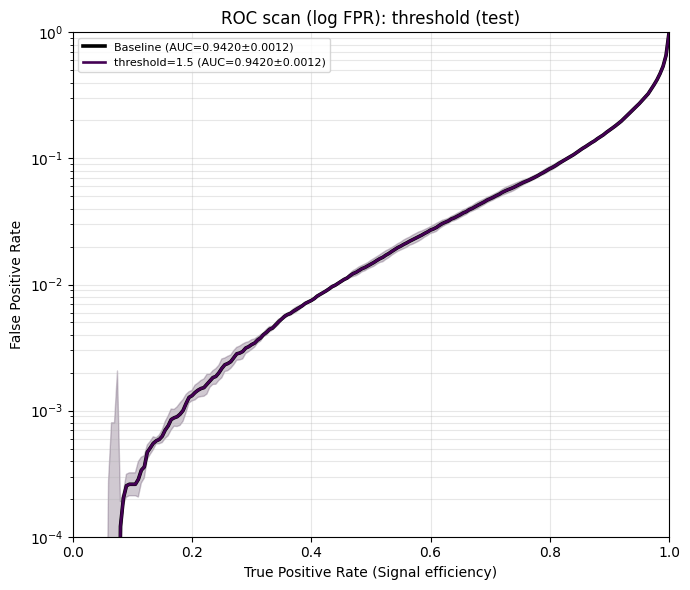

Saved figure: d:\PracticeTagging\tagging\Baseline\runs\hlt_effect_ablation\figs\roc_scan_resolution_logfpr.png


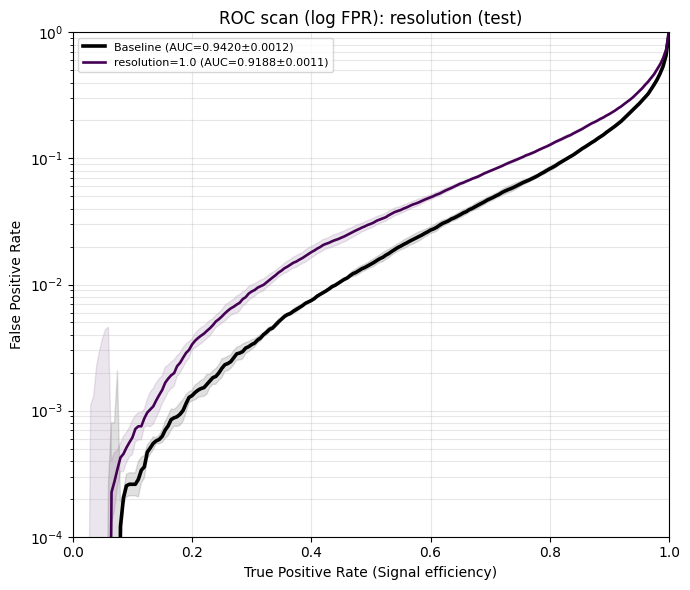

Saved figure: d:\PracticeTagging\tagging\Baseline\runs\hlt_effect_ablation\figs\roc_scan_merge_radius_logfpr.png


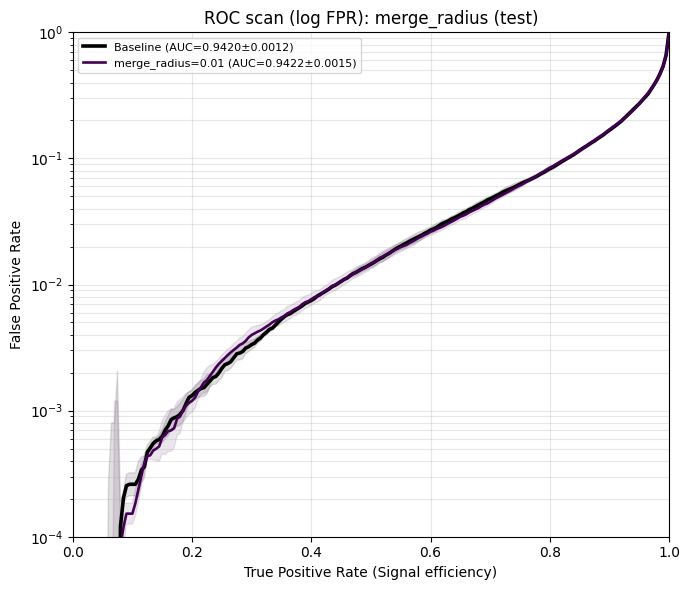

Saved figure: d:\PracticeTagging\tagging\Baseline\runs\hlt_effect_ablation\figs\roc_scan_effloss_logfpr.png


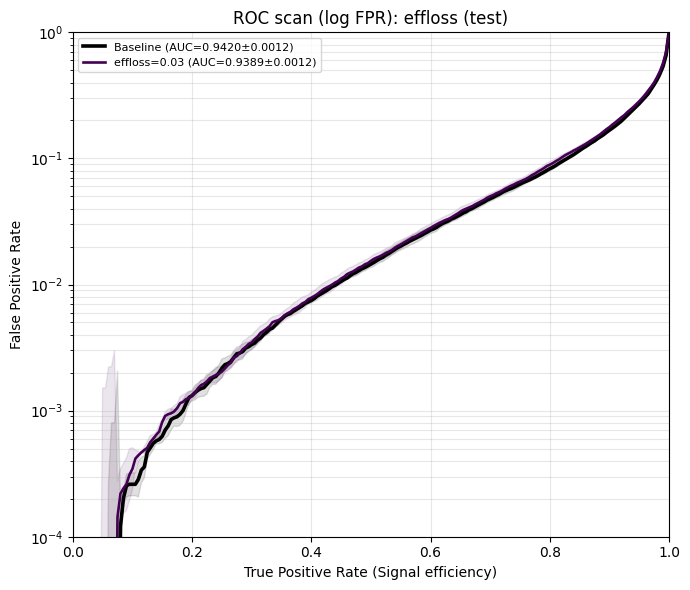

In [7]:
# Plot: one ROC figure per effect (include baseline) in HEP-style
# x-axis: TPR (signal efficiency)
# y-axis: FPR (background efficiency) with log scale

tpr_grid = np.linspace(0.0, 1.0, int(SCAN.get('fpr_grid_n', 201)))
EPS = 1e-12


def _interp_fpr_at_tpr(fpr: np.ndarray, tpr: np.ndarray, grid: np.ndarray) -> np.ndarray:
    # ROC 输出里 tpr 通常是非降序，但可能有重复值；这里做一次排序并去重，保证可插值
    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)
    order = np.argsort(tpr)
    t = tpr[order]
    f = fpr[order]
    # 去除重复 tpr（保留最小 fpr，有利于稳定）
    uniq_t, idx = np.unique(t, return_index=True)
    uniq_f = f[idx]
    if uniq_t.shape[0] < 2:
        return np.full_like(grid, fill_value=float(uniq_f[0]) if uniq_f.size else 1.0, dtype=np.float64)
    return np.interp(grid, uniq_t, uniq_f)


def _mean_curve_fpr(res_by_seed: dict):
    # res_by_seed: seed -> (fpr,tpr,auc)
    fprs = []
    aucs = []
    for s, (fpr, tpr, auc) in res_by_seed.items():
        fprs.append(_interp_fpr_at_tpr(np.asarray(fpr), np.asarray(tpr), tpr_grid))
        aucs.append(float(auc))
    fprs = np.stack(fprs, axis=0)  # [R,G]

    # 在 log 空间求均值/方差，避免高 FPR 区域主导
    lf = np.log10(np.clip(fprs, EPS, 1.0))
    lf_m = lf.mean(axis=0)
    lf_s = lf.std(axis=0)
    f_m = np.clip(10.0 ** lf_m, EPS, 1.0)
    f_lo = np.clip(10.0 ** (lf_m - lf_s), EPS, 1.0)
    f_hi = np.clip(10.0 ** (lf_m + lf_s), EPS, 1.0)

    aucs = np.asarray(aucs, dtype=np.float64)
    return f_m, f_lo, f_hi, float(aucs.mean()), float(aucs.std())


def plot_effect(effect_name: str, values):
    res = scan_results[effect_name]

    # baseline
    base_f, base_lo, base_hi, base_auc_m, base_auc_s = _mean_curve_fpr(res['baseline'])

    plt.figure(figsize=(7.0, 6.0))
    plt.semilogy(tpr_grid, base_f, color='black', lw=2.6, label=f"Baseline (AUC={base_auc_m:.4f}±{base_auc_s:.4f})")
    plt.fill_between(tpr_grid, base_lo, base_hi, color='black', alpha=0.12)

    # effect curves
    cmap = plt.get_cmap('viridis')
    vals = list(values)
    for i, v in enumerate(vals):
        f_m, f_lo, f_hi, auc_m, auc_s = _mean_curve_fpr(res[float(v)])
        c = cmap(i / max(1, len(vals) - 1))
        plt.semilogy(tpr_grid, f_m, color=c, lw=1.9, label=f"{effect_name}={v} (AUC={auc_m:.4f}±{auc_s:.4f})")
        plt.fill_between(tpr_grid, f_lo, f_hi, color=c, alpha=0.10)

    plt.xlabel('True Positive Rate (Signal efficiency)')
    plt.ylabel('False Positive Rate')
    plt.title(f"ROC scan (log FPR): {effect_name} (test)")
    plt.ylim(1e-4, 1.0)
    plt.xlim(0.0, 1.0)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(loc='upper left', fontsize=8)
    plt.tight_layout()

    out_path = os.path.join(CONFIG['io']['fig_dir'], f"roc_scan_{effect_name}_logfpr.png")
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    print('Saved figure:', out_path)
    plt.show()


plot_effect('threshold', SCAN['hlt_threshold_vals'])
plot_effect('resolution', SCAN['resolution_scales'])
plot_effect('merge_radius', SCAN['merge_radii'])
plot_effect('effloss', SCAN['effloss_vals'])
